In [1]:
import pandas as pd
import re

In [2]:
# ===== Clean MSCI World Data =====
def clean_msci_world(filepath):
    df = (
        pd.read_csv(filepath, skiprows=7, sep=';', decimal=',')
        .dropna(subset=['Ticker', 'Name'])
    )
    # Clean numeric columns
    num_cols = ['Market Value', 'Notional Value', 'Quantity', 'Price']
    for col in num_cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace('.', '', regex=False)
                .str.replace(',', '.')
            )
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Select and rename columns
    keep_cols = {
        'Ticker': 'ticker',
        'Name': 'name',
        'Market Value': 'market_value',
        'Notional Value': 'notional_value',
        'Location': 'location',
        'Sector': 'sector',
        'Asset Class': 'asset_class',
        'Weight (%)': 'weight',
    }
    df = df[list(keep_cols.keys())].rename(columns=keep_cols)
    
    return df

In [4]:
# Import and clean the MSCI World data
df = clean_msci_world('data/00_raw/msci_world.csv')
df.head()

,ticker,name,market_value,notional_value,location,sector,asset_class,weight
0,NVDA,NVIDIA CORP,2.113071e+08,2.113071e+08,United States,Information Technology,Equity,4.49
1,MSFT,MICROSOFT CORP,2.089668e+08,2.089668e+08,United States,Information Technology,Equity,4.44
2,AAPL,APPLE INC,1.929814e+08,1.929814e+08,United States,Information Technology,Equity,4.10
3,AMZN,AMAZON COM INC,1.250029e+08,1.250029e+08,United States,Consumer Discretionary,Equity,2.65
4,META,META PLATFORMS INC CLASS A,8.975737e+07,8.975737e+07,United States,Communication,Equity,1.91


In [5]:
# Total number of companies, of sectors and locations (countries)
total_companies = df['ticker'].nunique()
total_sectors = df['sector'].nunique()
total_locations = df['location'].nunique()
print(f'Total companies: {total_companies}')
print(f'Total sectors: {total_sectors}')
print(f'Total locations: {total_locations}')

Total companies: 1342
Total sectors: 12
Total locations: 25


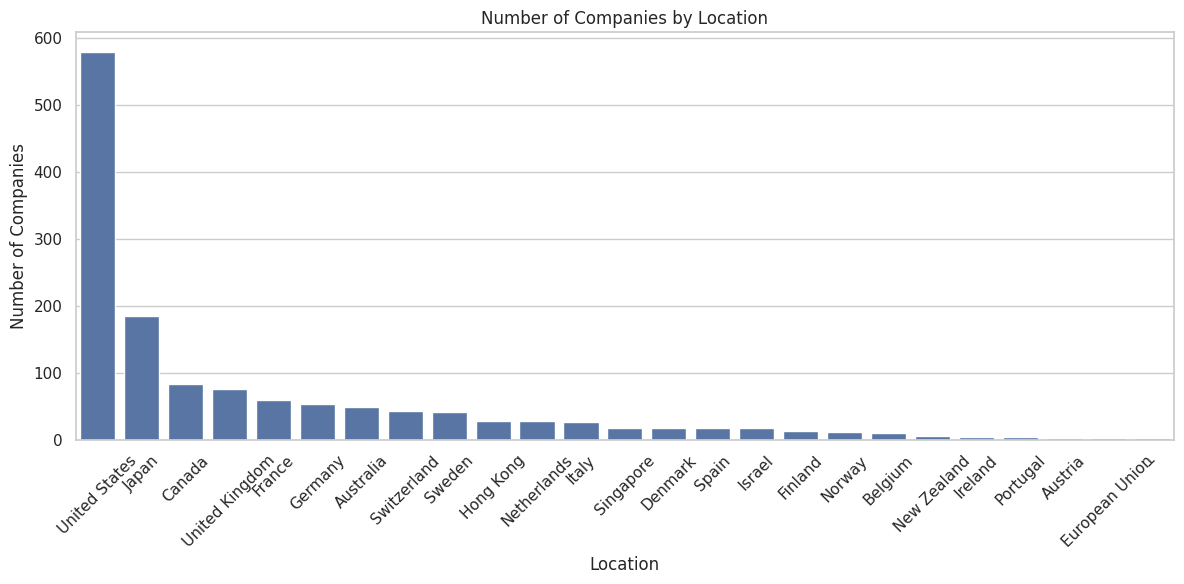

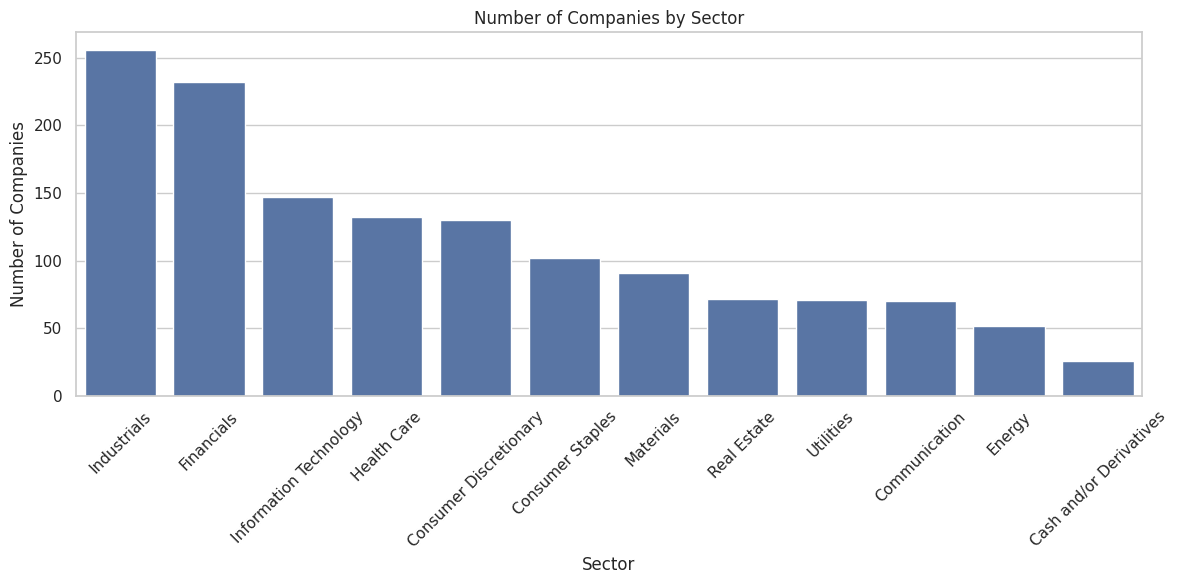

In [8]:
# Draw graphs for location and sector
def draw_graphs(df):
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Set the style
    sns.set(style="whitegrid")

    # Plot for Location
    plt.figure(figsize=(12, 6))
    location_counts = df['location'].value_counts()
    sns.barplot(x=location_counts.index, y=location_counts.values)
    plt.title('Number of Companies by Location')
    plt.xlabel('Location')
    plt.ylabel('Number of Companies')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Plot for Sector
    plt.figure(figsize=(12, 6))
    sector_counts = df['sector'].value_counts()
    sns.barplot(x=sector_counts.index, y=sector_counts.values)
    plt.title('Number of Companies by Sector')
    plt.xlabel('Sector')
    plt.ylabel('Number of Companies')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Draw the graphs
draw_graphs(df)